<a href="https://colab.research.google.com/github/dgonzales1222/greends_avcad_exercises/blob/main/exercise_05/avcad_ex05_dgonzales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advance Visualization of Complex Agro-environmental Data

# **Exercise 5**

Danilo III O. Gonzales (29225) <br>
Master's in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `If I have a 2 column figure how do I put the legend outside since both share the same color legend below the figure centered in the image?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

### Exercise Questions

In this exercise you will use again the dataset in `EFIplus_medit.zip` to perform some hypothesis testing:

1. Test whether the means (or medians) of "Mean Annual Temperature" between presence and absence sites of *Salmo trutta fario* (Brown Trout) are equal using an appropriate test. Use both standardized and non-standardized values and compare results.
2. Test if the frequency of sites with presence and absence of *Salmo trutta fario* (Brown Trout) are independent from the country.
3. Test whether there are differences in the mean elevation in the upstream catchment (Elevation_mean_catch) among the eight most sampled catchments. For which pairs of catchments are these differences significant?
4. Run the non-parametric equivalent of the test you used in the previous exercise and compare with the ANOVA test.

## 1. Setup and Data Preparation

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import zscore

In [2]:
# Load data from GitHub
url = 'https://github.com/dgonzales1222/greends_avcad_exercises/raw/main/exercise_03/EFIplus_medit.zip'
df = pd.read_csv(url, compression='zip', sep=';')

# Clean dataset
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))

# Drop rows with NaN
df2 = df.dropna()
print(f"Shape after dropna: {df2.shape}")

Shape after dropna: (2822, 154)


In [3]:
# @title Global Plot Settings

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
})

---
## 3. Q1: Test whether the means (or medians) of temp_ann between presence and absence sites of Brown Trout are equal

We use two tests:
- **Independent samples t-test** (parametric) — compares means, assumes normality and equal-ish variance
- **Mann-Whitney U test** (non-parametric) — compares medians/ranks, no normality assumption

Both are run on the original (non-standardized) values and on z-score standardized values to compare results.

In [4]:
# Create presence/absence column
df2 = df2.copy()
df2['trout_present'] = df2['Salmo trutta fario'].apply(lambda x: 'Present' if x > 0 else 'Absent')

# Split groups
present = df2[df2['trout_present'] == 'Present']['temp_ann']
absent = df2[df2['trout_present'] == 'Absent']['temp_ann']

print("Summary statistics:")
print(f"  Present: n={len(present)}, mean={present.mean():.2f}, median={present.median():.2f}, std={present.std():.2f}")
print(f"  Absent:  n={len(absent)}, mean={absent.mean():.2f}, median={absent.median():.2f}, std={absent.std():.2f}")

Summary statistics:
  Present: n=2042, mean=12.75, median=13.00, std=1.56
  Absent:  n=780, mean=15.21, median=15.40, std=1.55


#### Hypothesis Testing

**Hypotheses (t-test):**
- $H_0$: The mean temp_ann is equal between presence and absence sites ($\mu_{present} = \mu_{absent}$)
- $H_A$: The mean temp_ann is not equal between presence and absence sites ($\mu_{present} \neq \mu_{absent}$)

**Hypotheses (Mann-Whitney U):**
- $H_0$: The distributions of temp_ann are equal between presence and absence sites
- $H_A$: The distributions of temp_ann are not equal between presence and absence sites

In [5]:
# @title Non-standardized Values

# Independent samples t-test (non-standardized)
t_stat, p_ttest = stats.ttest_ind(present, absent)
print("=== Non-standardized values ===")
print(f"Independent t-test:  t = {t_stat:.4f}, p = {p_ttest:.6e}")

# Mann-Whitney U test (non-standardized)
u_stat, p_mann = stats.mannwhitneyu(present, absent, alternative='two-sided')
print(f"Mann-Whitney U test: U = {u_stat:.0f}, p = {p_mann:.6e}")

print(f"\nBoth tests: {'Reject H₀' if p_ttest < 0.05 else 'Fail to reject H₀'} (α = 0.05)")
print("The means/medians of temp_ann are significantly different between presence and absence sites.")

=== Non-standardized values ===
Independent t-test:  t = -37.4542, p = 1.470399e-249
Mann-Whitney U test: U = 220336, p = 1.145981e-194

Both tests: Reject H₀ (α = 0.05)
The means/medians of temp_ann are significantly different between presence and absence sites.


#### Standardized values (z-scores)

Standardizing converts all values to z-scores: $z = \frac{x - \mu}{\sigma}$

This rescales the data to have mean = 0 and std = 1, but preserves the relative differences between groups.

In [6]:
# Standardize temp_ann using z-score
df2['temp_ann_z'] = zscore(df2['temp_ann'])

present_z = df2[df2['trout_present'] == 'Present']['temp_ann_z']
absent_z = df2[df2['trout_present'] == 'Absent']['temp_ann_z']

# t-test (standardized)
t_stat_z, p_ttest_z = stats.ttest_ind(present_z, absent_z)
print("=== Standardized values (z-scores) ===")
print(f"Independent t-test:  t = {t_stat_z:.4f}, p = {p_ttest_z:.6e}")

# Mann-Whitney U (standardized)
u_stat_z, p_mann_z = stats.mannwhitneyu(present_z, absent_z, alternative='two-sided')
print(f"Mann-Whitney U test: U = {u_stat_z:.0f}, p = {p_mann_z:.6e}")

=== Standardized values (z-scores) ===
Independent t-test:  t = -37.4542, p = 1.470399e-249
Mann-Whitney U test: U = 220336, p = 1.145981e-194


In [7]:
# @title Comparison: Standardized vs Non-standardized
print(f"{'Test':<20} {'Non-standardized':>20} {'Standardized':>20}")
print("-" * 62)
print(f"{'t-test (t-stat)':<20} {t_stat:>20.4f} {t_stat_z:>20.4f}")
print(f"{'t-test (p-value)':<20} {p_ttest:>20.6e} {p_ttest_z:>20.6e}")
print(f"{'Mann-Whitney (U)':<20} {u_stat:>20.0f} {u_stat_z:>20.0f}")
print(f"{'Mann-Whitney (p)':<20} {p_mann:>20.6e} {p_mann_z:>20.6e}")

Test                     Non-standardized         Standardized
--------------------------------------------------------------
t-test (t-stat)                  -37.4542             -37.4542
t-test (p-value)            1.470399e-249        1.470399e-249
Mann-Whitney (U)                   220336               220336
Mann-Whitney (p)            1.145981e-194        1.145981e-194


The t-statistic and p-values are identical for both standardized and non-standardized values. This is expected because z-score standardization is a linear transformation that shifts and scales all values equally, thereby preserving the relative differences between groups. The Mann-Whitney U test also yields the same results because it is rank-based, and standardization does not change the rank order of values. Standardization is effective when you're comparing variables with different units or scales.

Both tests strongly reject $H_0$ (p ≈ 0), confirming that Brown Trout presence and absence sites have significantly different mean annual temperatures.

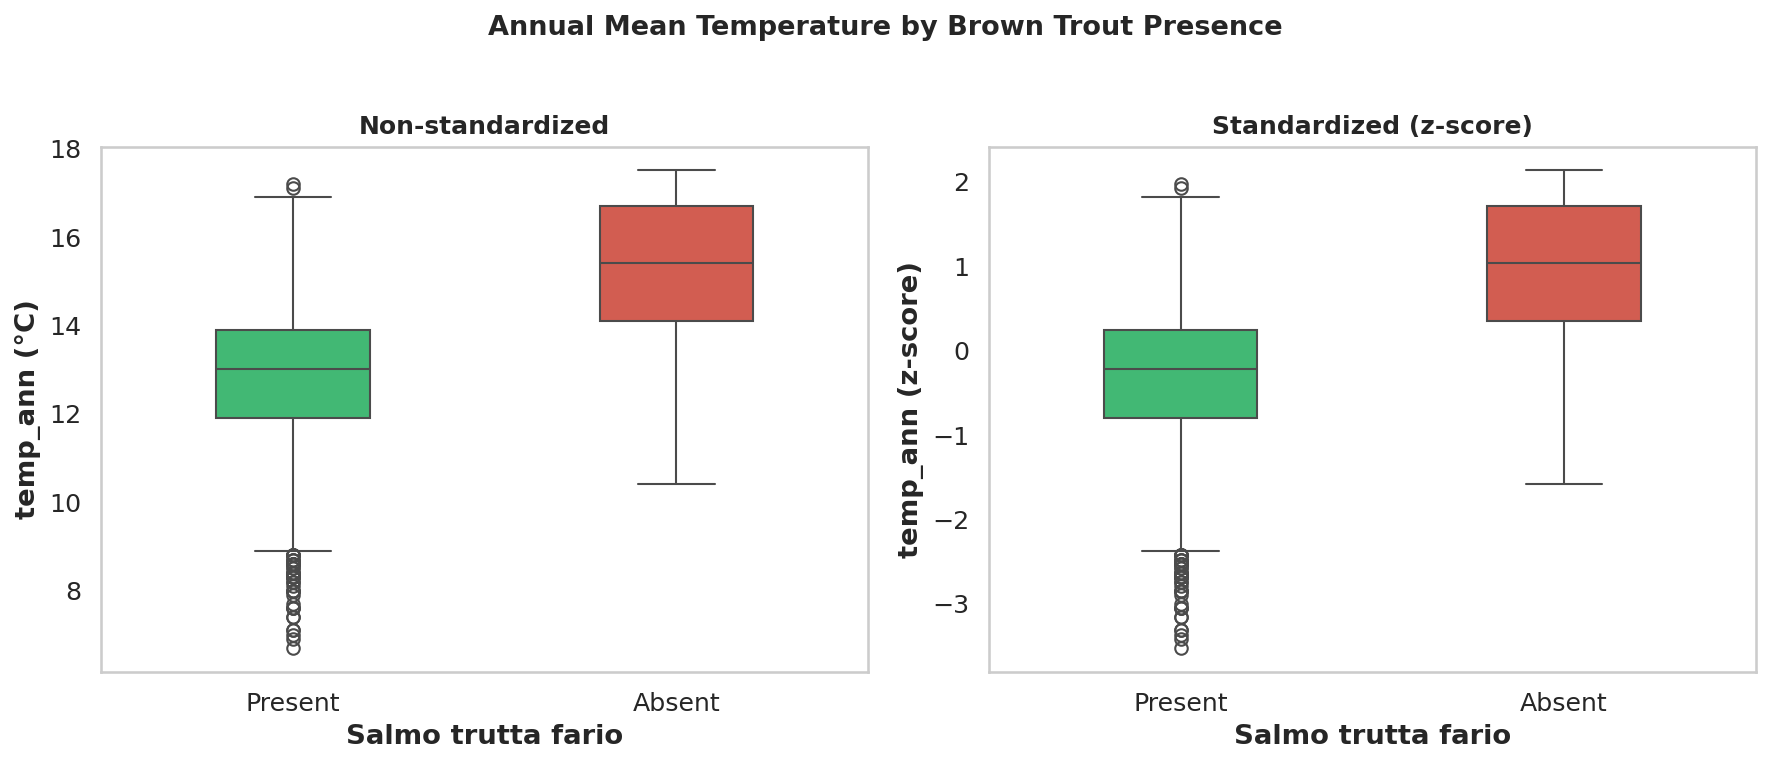

In [8]:
# @title Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Non-standardized
ax = axes[0]
sns.boxplot(x='trout_present', y='temp_ann', data=df2, ax=ax,
            hue='trout_present', palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
            order=['Present', 'Absent'], width=0.4, legend=False)
ax.set_title("Non-standardized", fontsize=12)
ax.set_xlabel("Salmo trutta fario")
ax.set_ylabel("temp_ann (°C)")
ax.grid(False)

# Standardized
ax = axes[1]
sns.boxplot(x='trout_present', y='temp_ann_z', data=df2, ax=ax,
            hue='trout_present', palette={'Present': '#2ecc71', 'Absent': '#e74c3c'},
            order=['Present', 'Absent'], width=0.4, legend=False)
ax.set_title("Standardized (z-score)", fontsize=12)
ax.set_xlabel("Salmo trutta fario")
ax.set_ylabel("temp_ann (z-score)")
ax.grid(False)

fig.suptitle("Annual Mean Temperature by Brown Trout Presence", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Q2: Test if the frequency of Brown Trout presence/absence is independent from the country

We use the **Chi-squared test of independence** to test whether trout presence is associated with the country.

**Hypotheses:**
- $H_0$: The frequency of Brown Trout presence/absence is **independent** from the country
- $H_A$: The frequency of Brown Trout presence/absence is **not independent** from the country (i.e., there is an association)

In [11]:
# @title Create contingency table

contingency = pd.crosstab(df2['Country'], df2['trout_present'])
print("Contingency Table (Observed Frequencies):\n")
print(contingency)
print(f"\nTotal sites: {contingency.values.sum()}")

Contingency Table (Observed Frequencies):

trout_present  Absent  Present
Country                       
Italy              26       25
Portugal          614      252
Spain             140     1765

Total sites: 2822


In [13]:
# @title Chi-squared Test

chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-squared Test of Independence")
print(f"  χ² statistic: {chi2:.4f}")
print(f"  p-value:      {p_chi:.6e}")
print(f"  Degrees of freedom: {dof}")
print(f"\nExpected Frequencies:\n")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print(f"\nConclusion: {'Reject H₀' if p_chi < 0.05 else 'Fail to reject H₀'} (α = 0.05)")

Chi-squared Test of Independence
  χ² statistic: 1216.3927
  p-value:      7.305892e-265
  Degrees of freedom: 2

Expected Frequencies:

trout_present  Absent  Present
Country                       
Italy            14.1     36.9
Portugal        239.4    626.6
Spain           526.5   1378.5

Conclusion: Reject H₀ (α = 0.05)


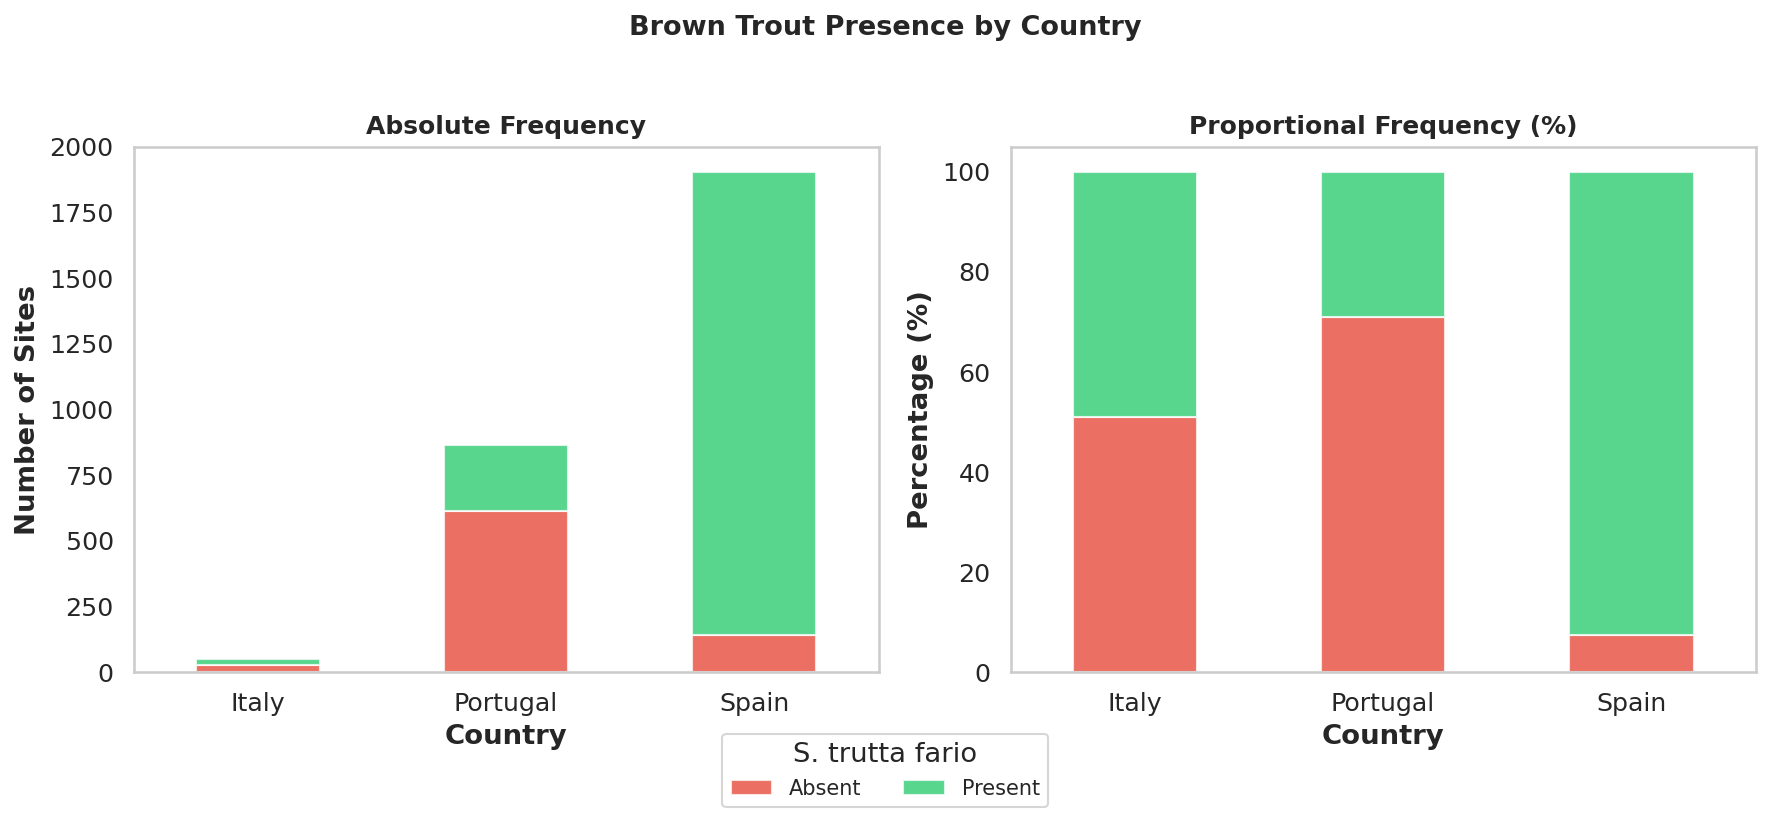

In [15]:
# Proportional stacked bar plot
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Absolute counts
contingency.plot(kind='bar', stacked=True, ax=axes[0],
                 color={'Absent': '#e74c3c', 'Present': '#2ecc71'}, alpha=0.8)
axes[0].set_title("Absolute Frequency", fontsize=12)
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Number of Sites")
axes[0].tick_params(axis='x', rotation=0)
axes[0].get_legend().remove()
axes[0].grid(False)

# Proportional
contingency_pct.plot(kind='bar', stacked=True, ax=axes[1],
                     color={'Absent': '#e74c3c', 'Present': '#2ecc71'}, alpha=0.8)
axes[1].set_title("Proportional Frequency (%)", fontsize=12)
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=0)
axes[1].get_legend().remove()
axes[1].grid(False)

fig.suptitle("Brown Trout Presence by Country", fontsize=13, fontweight='bold', y=1.02)

# Single shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="S. trutta fario", loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=10)

plt.tight_layout()
plt.show()

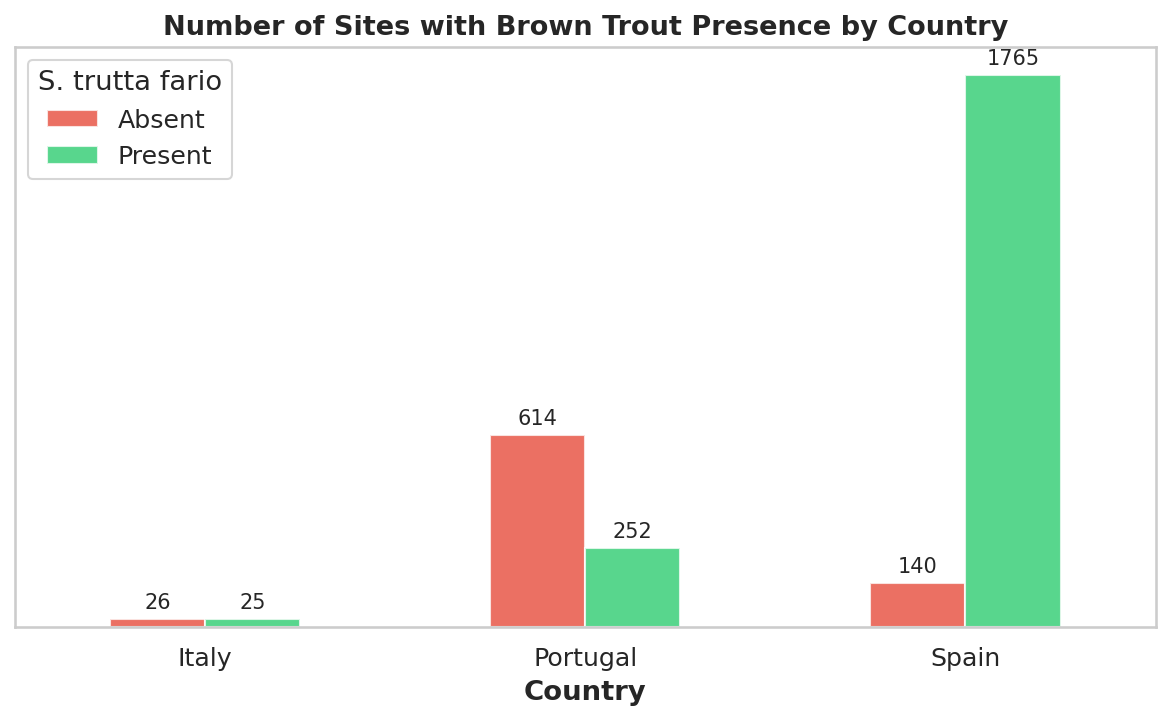

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
contingency.plot(kind='bar', ax=ax, color={'Absent': '#e74c3c', 'Present': '#2ecc71'}, alpha=0.8)
ax.set_title("Number of Sites with Brown Trout Presence by Country", fontsize=13, fontweight='bold')
ax.set_xlabel("Country")
ax.set_ylabel("")
ax.set_yticks([])
ax.tick_params(axis='x', rotation=0)
ax.legend(title="S. trutta fario")
ax.grid(False)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.tight_layout()
plt.show()